# exp01 — EDA + Предобработка данных

## Цель
Провести разведочный анализ датасета подержанных автомобилей (Craigslist),
понять структуру данных, распределение признаков и целевой переменной,
выполнить очистку и сохранить обработанный датасет для следующего эксперимента.

## Данные
- **Источник:** [Craigslist Cars & Trucks — Kaggle](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)
- **Файл:** `vehicles.csv` (~1.45 ГБ, ~426k объявлений)
- **Загрузка:** автоматически через `kaggle` CLI (см. ячейку ниже)

## 0. Конфигурация путей

In [22]:
from pathlib import Path

PROJECT_ROOT  = Path('..')                           # корень проекта
DATA_RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'        # сырые данные
DATA_PROC_DIR = PROJECT_ROOT / 'data' / 'processed'  # обработанные данные
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'exp01_EDA' # графики и артефакты

# Создаём папки, если их нет
for d in [DATA_RAW_DIR, DATA_PROC_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_FILE  = DATA_RAW_DIR  / 'vehicles.csv'
PROC_FILE = DATA_PROC_DIR / 'vehicles_clean.parquet'

print(f'RAW_FILE  : {RAW_FILE}')
print(f'PROC_FILE : {PROC_FILE}')
print(f'ARTIFACTS : {ARTIFACTS_DIR}')

RAW_FILE  : ../data/raw/vehicles.csv
PROC_FILE : ../data/processed/vehicles_clean.parquet
ARTIFACTS : ../artifacts/exp01_EDA


## 1. Установка зависимостей

In [23]:
!pip install kaggle pandas numpy matplotlib seaborn pyarrow -q

## 2. Загрузка датасета с Kaggle

In [24]:
import os

if not RAW_FILE.exists():
    print('⬇Скачиваем датасет с Kaggle...')
    os.system(
        f'kaggle datasets download -d austinreese/craigslist-carstrucks-data '
        f'--path {DATA_RAW_DIR} --unzip'
    )
    # Kaggle распаковывает как vehicles.csv
    print(f'Готово: {RAW_FILE}')
else:
    print(f'Файл уже существует: {RAW_FILE}')

⬇Скачиваем датасет с Kaggle...
Dataset URL: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
License(s): CC0-1.0


100%|██████████| 262M/262M [00:24<00:00, 11.1MB/s] 



Готово: ../data/raw/vehicles.csv


## 3. Импорты

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
SAVE_FIG = True   # True — сохранять графики в ARTIFACTS_DIR

def savefig(name):
    if SAVE_FIG:
        path = ARTIFACTS_DIR / f'{name}.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'сохранено: {path}')

print('Импорты выполнены')

Импорты выполнены


## 4. Загрузка и первичный осмотр

In [26]:
df = pd.read_csv(RAW_FILE, low_memory=False)
print(f'Размер: {df.shape[0]:,} строк × {df.shape[1]} колонок')
df.head(5)

Размер: 426,880 строк × 26 колонок


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [27]:
print('=== Типы данных ===')
print(df.dtypes.to_string())

=== Типы данных ===
id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             float64
long            float64
posting_date     object


сохранено: ../artifacts/exp01_EDA/missing_values.png


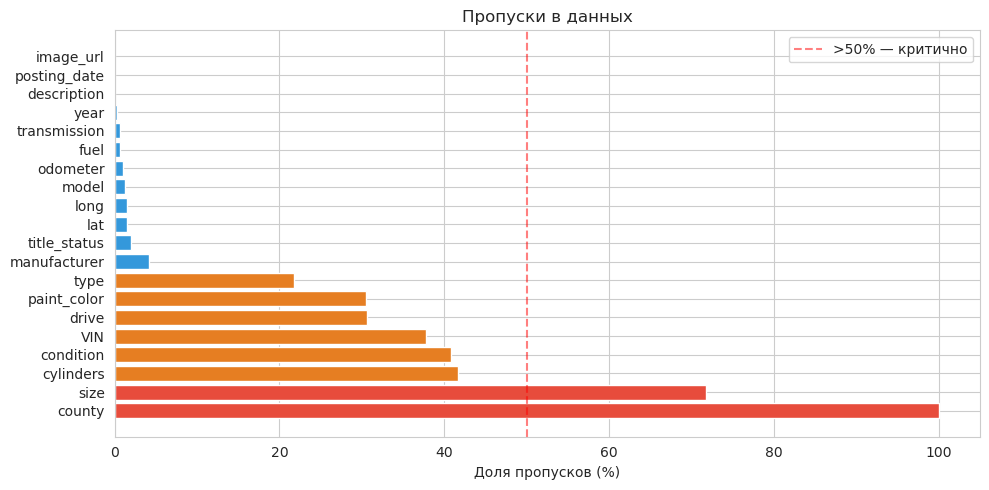

      column  missing_%
      county 100.000000
        size  71.767476
   cylinders  41.622470
   condition  40.785232
         VIN  37.725356
       drive  30.586347
 paint_color  30.501078
        type  21.752717
manufacturer   4.133714
title_status   1.930753
         lat   1.534155
        long   1.534155
       model   1.236179
    odometer   1.030735
        fuel   0.705819
transmission   0.598763
        year   0.282281
 description   0.016398
posting_date   0.015930
   image_url   0.015930


In [28]:
# Доля пропусков по каждой колонке
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['column', 'missing_%']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 50 else '#e67e22' if v > 20 else '#3498db'
          for v in missing_df['missing_%']]
ax.barh(missing_df['column'], missing_df['missing_%'], color=colors)
ax.set_xlabel('Доля пропусков (%)')
ax.set_title('Пропуски в данных')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='>50% — критично')
ax.legend()
plt.tight_layout()
savefig('missing_values')
plt.show()

print(missing_df.to_string(index=False))

## 5. Анализ целевой переменной (price)

In [29]:
print('=== Статистика по price ===')
print(df['price'].describe().round(0))
print(f'\nНулевые цены: {(df["price"] == 0).sum():,}')
print(f'Цены > 150k$: {(df["price"] > 150_000).sum():,}')

=== Статистика по price ===
count    4.268800e+05
mean     7.519900e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648600e+04
max      3.736929e+09
Name: price, dtype: float64

Нулевые цены: 32,895
Цены > 150k$: 196


сохранено: ../artifacts/exp01_EDA/price_distribution.png


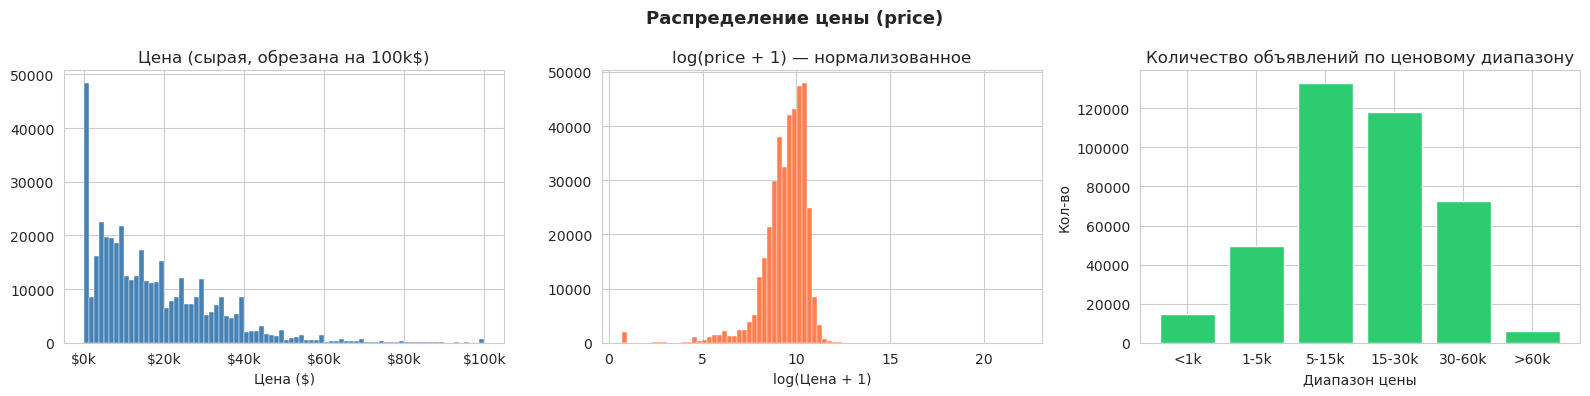

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Сырое распределение (до 100k)
axes[0].hist(df['price'].clip(0, 100_000), bins=80,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Цена (сырая, обрезана на 100k$)')
axes[0].set_xlabel('Цена ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Log-распределение
price_pos = df.loc[df['price'] > 0, 'price']
axes[1].hist(np.log1p(price_pos), bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('log(price + 1) — нормализованное')
axes[1].set_xlabel('log(Цена + 1)')

# Box plot по диапазонам
bins_labels = ['<1k', '1-5k', '5-15k', '15-30k', '30-60k', '>60k']
bins_vals   = [0, 1000, 5000, 15000, 30000, 60000, 1e9]
df_pos = df[df['price'] > 0].copy()
df_pos['price_range'] = pd.cut(df_pos['price'], bins=bins_vals, labels=bins_labels)
counts = df_pos['price_range'].value_counts().reindex(bins_labels)
axes[2].bar(bins_labels, counts.values, color='#2ecc71', edgecolor='white')
axes[2].set_title('Количество объявлений по ценовому диапазону')
axes[2].set_xlabel('Диапазон цены')
axes[2].set_ylabel('Кол-во')

plt.suptitle('Распределение цены (price)', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('price_distribution')
plt.show()

## 6. Анализ ключевых признаков

сохранено: ../artifacts/exp01_EDA/top_manufacturers.png


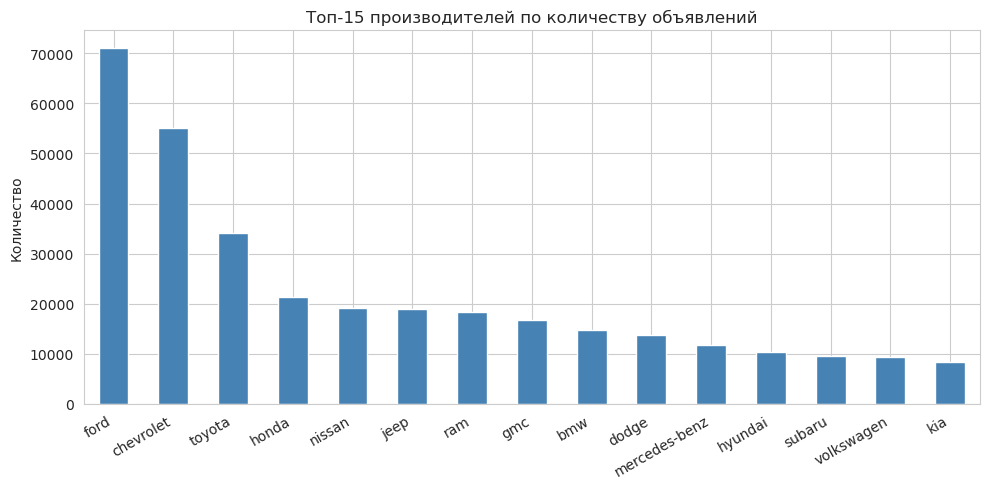

In [31]:
# Топ-15 производителей по количеству объявлений
top_manufacturers = df['manufacturer'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_manufacturers.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Топ-15 производителей по количеству объявлений')
ax.set_xlabel('')
ax.set_ylabel('Количество')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
savefig('top_manufacturers')
plt.show()

сохранено: ../artifacts/exp01_EDA/median_price_by_manufacturer.png


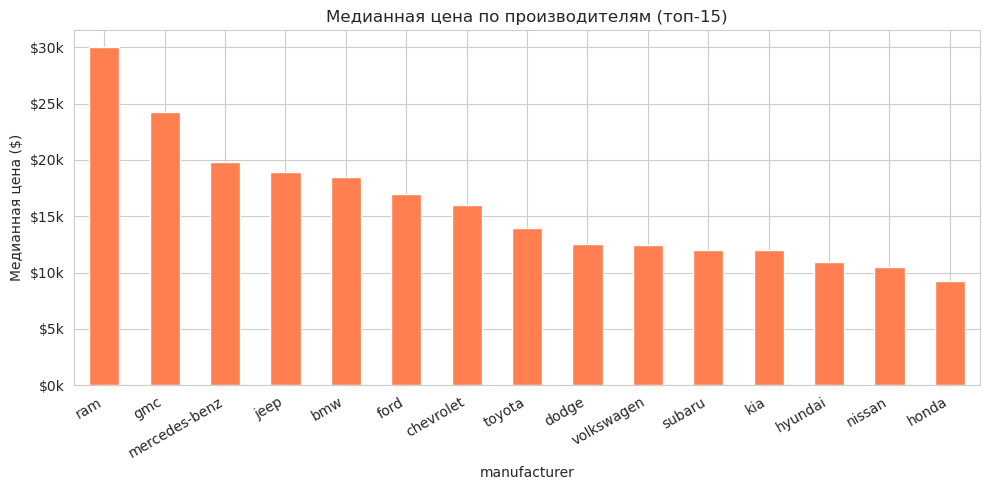

In [32]:
# Медианная цена по производителям (топ-15)
top_mfr_names = top_manufacturers.index.tolist()
df_top = df[(df['manufacturer'].isin(top_mfr_names)) &
            (df['price'].between(500, 150_000))].copy()

median_price = (df_top.groupby('manufacturer')['price']
                .median().reindex(top_mfr_names).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
median_price.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Медианная цена по производителям (топ-15)')
ax.set_ylabel('Медианная цена ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
savefig('median_price_by_manufacturer')
plt.show()

сохранено: ../artifacts/exp01_EDA/price_vs_odometer.png


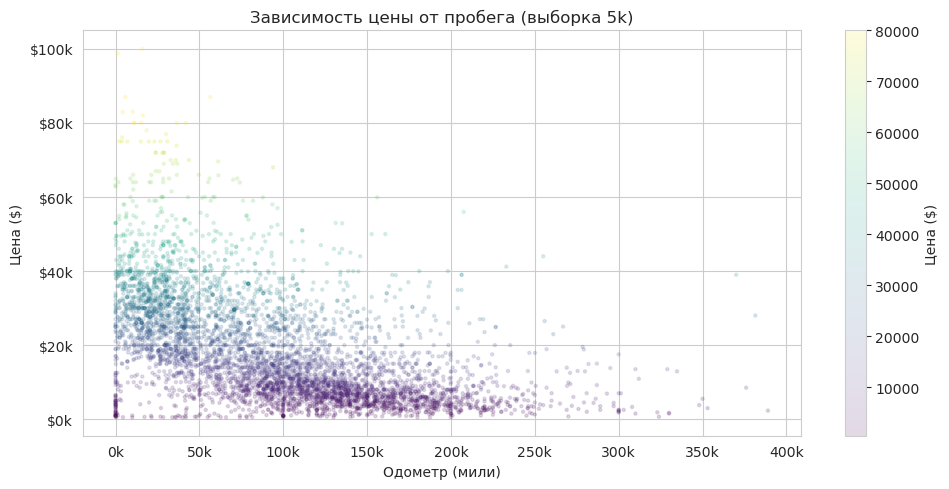

In [33]:
# Одометр vs Цена (scatter, семпл 5k точек)
df_sample = df[(df['price'].between(500, 100_000)) &
               (df['odometer'].between(0, 400_000))].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(df_sample['odometer'], df_sample['price'],
                alpha=0.15, s=5, c=df_sample['price'],
                cmap='viridis', norm=plt.Normalize(500, 80_000))
plt.colorbar(sc, ax=ax, label='Цена ($)')
ax.set_xlabel('Одометр (мили)')
ax.set_ylabel('Цена ($)')
ax.set_title('Зависимость цены от пробега (выборка 5k)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
savefig('price_vs_odometer')
plt.show()

сохранено: ../artifacts/exp01_EDA/price_by_year.png


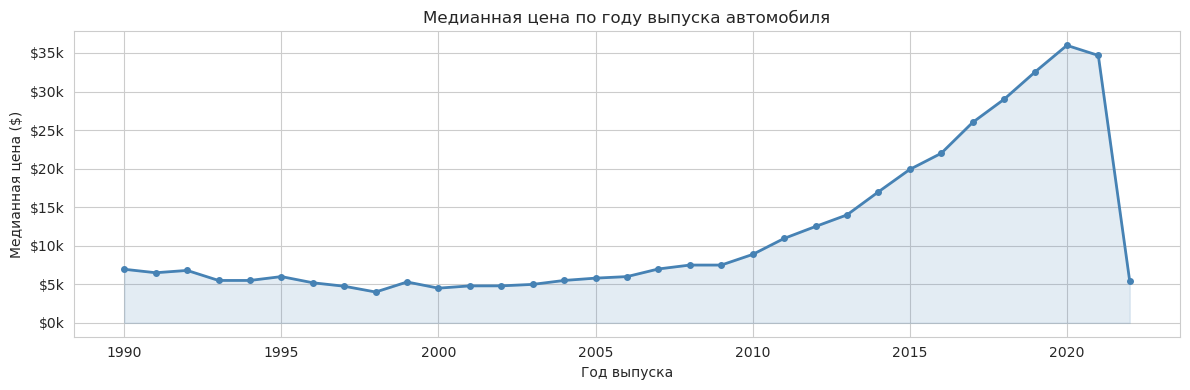

In [ ]:
# Год выпуска vs Медианная цена
df_yr = df[(df['price'].between(500, 100_000)) &
           (df['year'].between(1990, 2022))]
year_price = df_yr.groupby('year')['price'].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year_price['year'], year_price['price'], marker='o', markersize=4,
        color='steelblue', linewidth=2)
ax.fill_between(year_price['year'], year_price['price'], alpha=0.15, color='steelblue')
ax.set_xlabel('Год выпуска')
ax.set_ylabel('Медианная цена ($)')
ax.set_title('Медианная цена по году выпуска автомобиля')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
savefig('price_by_year')
plt.show()

сохранено: ../artifacts/exp01_EDA/categorical_features.png


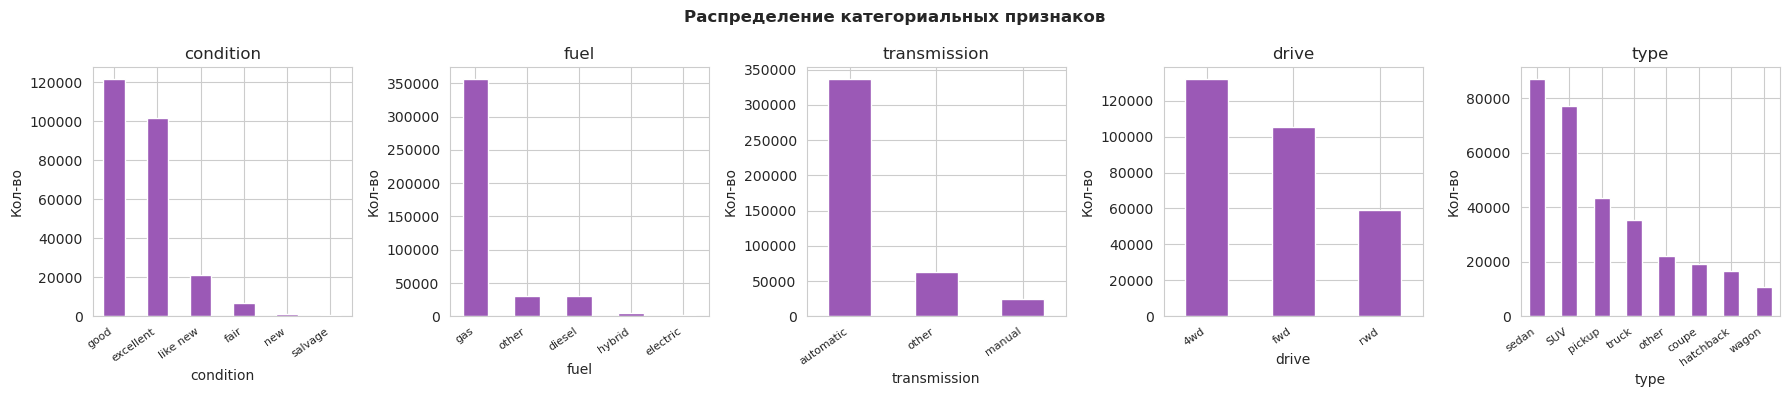

In [35]:
# Категориальные признаки: condition, fuel, transmission
cat_features = ['condition', 'fuel', 'transmission', 'drive', 'type']
fig, axes = plt.subplots(1, len(cat_features), figsize=(18, 4))

for ax, col in zip(axes, cat_features):
    counts = df[col].value_counts().head(8)
    counts.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Кол-во')

plt.suptitle('Распределение категориальных признаков', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('categorical_features')
plt.show()

## 7. Очистка и предобработка данных

In [ ]:
FEATURES = ['year', 'manufacturer', 'condition', 'cylinders',
            'fuel', 'odometer', 'title_status', 'transmission',
            'drive', 'type', 'paint_color', 'state']
TARGET = 'price'
CURRENT_YEAR = 2022

df_clean = df[FEATURES + [TARGET]].copy()
n0 = len(df_clean)
print(f'Исходно: {n0:,} строк')

Исходно: 426,880 строк


In [37]:
# Фильтрация выбросов
df_clean = df_clean[(df_clean[TARGET] >= 500) & (df_clean[TARGET] <= 150_000)]
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= CURRENT_YEAR)]
df_clean = df_clean[df_clean['odometer'] <= 500_000]
print(f'После фильтрации: {len(df_clean):,} строк (удалено {n0 - len(df_clean):,})')

После фильтрации: 372,504 строк (удалено 54,376)


In [38]:
# Feature engineering
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']
df_clean.drop(columns=['year'], inplace=True)

# Заполнение пропусков
CAT_COLS = ['manufacturer', 'condition', 'cylinders', 'fuel',
            'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
NUM_COLS = ['odometer', 'car_age']

for col in CAT_COLS:
    df_clean[col] = df_clean[col].fillna('unknown')
for col in NUM_COLS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f'Пропусков: {df_clean.isnull().sum().sum()}')
print(f'Итоговый датафрейм: {df_clean.shape}')
df_clean.head(5)

Пропусков: 0
Итоговый датафрейм: (372504, 13)


,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price,car_age
27,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,33590,10.0
28,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,22590,14.0
29,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,39590,4.0
30,toyota,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,al,30990,7.0
31,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,15000,11.0


сохранено: ../artifacts/exp01_EDA/feature_correlation.png


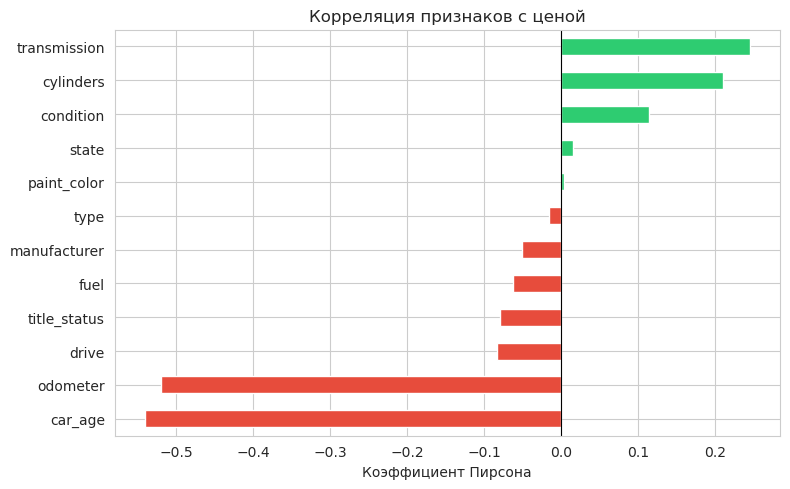

In [39]:
# Корреляция числовых признаков с ценой
from sklearn.preprocessing import LabelEncoder

df_enc = df_clean.copy()
le = LabelEncoder()
for col in CAT_COLS:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

corr = df_enc.corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция признаков с ценой')
ax.set_xlabel('Коэффициент Пирсона')
plt.tight_layout()
savefig('feature_correlation')
plt.show()

## 8. Сохранение артефактов

In [40]:
# Сохраняем обработанный датасет в parquet (быстрее и легче CSV)
df_clean.to_parquet(PROC_FILE, index=False)
size_mb = PROC_FILE.stat().st_size / 1024**2
print(f'Сохранён обработанный датасет: {PROC_FILE}')
print(f'Размер: {size_mb:.1f} МБ, строк: {len(df_clean):,}')

Сохранён обработанный датасет: ../data/processed/vehicles_clean.parquet
Размер: 3.3 МБ, строк: 372,504
